<a href="https://www.kaggle.com/code/aabdollahii/linear-regression-movie-metadata?scriptVersionId=324017358" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aabdollahii/movie-metadata/movies_metadata.csv


In [2]:
# load data
df = pd.read_csv("/kaggle/input/datasets/aabdollahii/movie-metadata/movies_metadata.csv")

# basic look
print("shape:", df.shape)
print()

print("columns:")
print(df.columns.tolist())
print()

# first rows
print("head:")
print(df.head())
print()

# data types
print("dtypes:")
print(df.dtypes)
print()


shape: (45466, 24)

columns:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

head:
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 

/tmp/ipykernel_16/3997383886.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/aabdollahii/movie-metadata/movies_metadata.csv")


In [3]:
# convert to numeric
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

# pick only needed cols
cols = ['budget', 'runtime', 'vote_average', 'vote_count', 'popularity', 'revenue']
df = df[cols]

# drop NaN
df = df.dropna()

# count zeros in each col before removing
print("zero counts per column:")
for c in cols:
    zero_cnt = (df[c] == 0).sum()
    print(f"  {c}: {zero_cnt}")

# drop zeros in budget and revenue (no real data)
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]

print("\nclean shape:", df.shape)
print(df.describe())


zero counts per column:
  budget: 36323
  runtime: 1558
  vote_average: 2899
  vote_count: 2800
  popularity: 60
  revenue: 37801

clean shape: (5380, 6)
             budget      runtime  vote_average    vote_count   popularity  \
count  5.380000e+03  5380.000000   5380.000000   5380.000000  5380.000000   
mean   3.109946e+07   109.827695      6.273829    732.445353     9.776052   
std    4.016490e+07    22.041188      0.925280   1251.597415    13.819078   
min    1.000000e+00     0.000000      0.000000      0.000000     0.000001   
25%    5.027750e+06    95.000000      5.700000     77.000000     5.445833   
50%    1.700000e+07   106.000000      6.300000    276.500000     8.389338   
75%    4.000000e+07   120.000000      6.900000    798.750000    11.720391   
max    3.800000e+08   338.000000      9.100000  14075.000000   547.488298   

            revenue  
count  5.380000e+03  
mean   9.033491e+07  
std    1.661531e+08  
min    1.000000e+00  
25%    7.016471e+06  
50%    2.992061e+07 

to many zeros in revenue and budget based on we talked these are not valid valuse in our matrix

In [4]:
# shuffle first
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df[['budget', 'runtime', 'vote_average', 'vote_count', 'popularity']].values
y = df['revenue'].values

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)


train: (3765, 5) val: (808, 5) test: (807, 5)


In [5]:
df.head()

,budget,runtime,vote_average,vote_count,popularity,revenue
0,14000000.0,118.0,4.5,137.0,8.266984,30749142.0
1,10920000.0,159.0,7.4,45.0,2.009033,19660000.0
2,18000000.0,95.0,5.6,115.0,6.696292,39321715.0
3,25000000.0,87.0,4.4,107.0,11.430964,15843608.0
4,3000000.0,90.0,4.7,3.0,0.445269,1957000.0


In [6]:
# scale using train stats only
# we can use readymade functions but why not ?



X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

y_mean = y_train.mean()
y_std  = y_train.std()

y_train = (y_train - y_mean) / y_std
y_val   = (y_val   - y_mean) / y_std
y_test  = (y_test  - y_mean) / y_std

print("X_train mean (should be 0):", X_train.mean(axis=0).round(3))


X_train mean (should be 0): [ 0.  0.  0. -0. -0.]


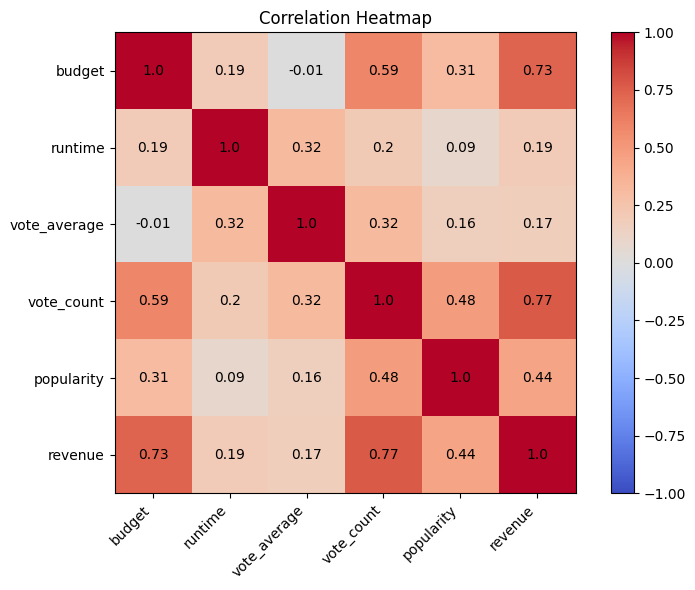

In [7]:
# Corr heatmap 

cols = ['budget', 'runtime', 'vote_average', 'vote_count', 'popularity', 'revenue']
data = df[cols].values

corr = np.corrcoef(data, rowvar=False)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, round(corr[i, j], 2), ha='center', va='center', color='black')

fig.colorbar(im)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [8]:
# linear model
lin = LinearRegression()
lin.fit(X_train, y_train)

print("linear train mse:", round(mean_squared_error(y_train, lin.predict(X_train)), 4))
print("linear val   mse:", round(mean_squared_error(y_val,   lin.predict(X_val)),   4))


best_degree = None
best_val_mse = None

for d in [1, 2, 3, 4]:
    poly_try = PolynomialFeatures(degree=d, include_bias=False)
    Xp_tr = poly_try.fit_transform(X_train)
    Xp_va = poly_try.transform(X_val)

    m = LinearRegression()
    m.fit(Xp_tr, y_train)

    val_mse = mean_squared_error(y_val, m.predict(Xp_va))
    print("degree", d, " val mse:", round(val_mse, 4))

    if best_val_mse is None or val_mse < best_val_mse:
        best_val_mse = val_mse
        best_degree = d

print("best degree picked by validation:", best_degree)


poly = PolynomialFeatures(degree=best_degree, include_bias=False)
Xp_train = poly.fit_transform(X_train)
Xp_val   = poly.transform(X_val)
Xp_test  = poly.transform(X_test)

pmodel = LinearRegression()
pmodel.fit(Xp_train, y_train)

print("poly train mse:", round(mean_squared_error(y_train, pmodel.predict(Xp_train)), 4))
print("poly val   mse:", round(mean_squared_error(y_val,   pmodel.predict(Xp_val)),   4))


lin_pred = lin.predict(X_test)
lin_mse = mean_squared_error(y_test, lin_pred)
lin_r2  = r2_score(y_test, lin_pred)

poly_pred = pmodel.predict(Xp_test)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_r2  = r2_score(y_test, poly_pred)

print("linear test mse:", round(lin_mse, 4))
print("linear test r2 :", round(lin_r2, 4))
print("poly   test mse:", round(poly_mse, 4))
print("poly   test r2 :", round(poly_r2, 4))


linear train mse: 0.2823
linear val   mse: 0.3742
degree 1  val mse: 0.3742
degree 2  val mse: 0.2947
degree 3  val mse: 0.3332
degree 4  val mse: 6.0867
best degree picked by validation: 2
poly train mse: 0.2428
poly val   mse: 0.2947
linear test mse: 0.2835
linear test r2 : 0.686
poly   test mse: 0.2482
poly   test r2 : 0.7252


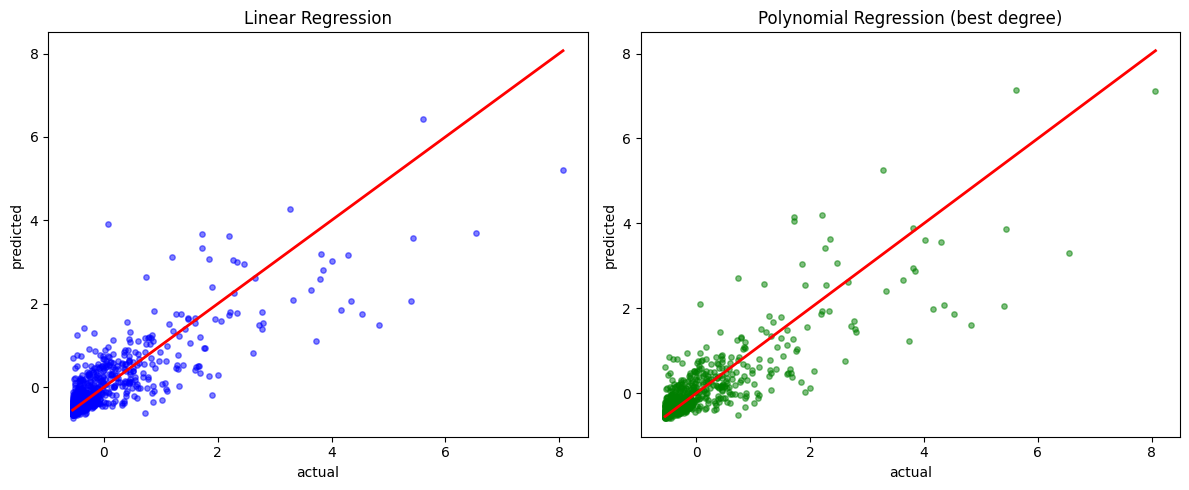

In [9]:
# plot actual vs predicted for both models
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lin_pred, color='blue', alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)   
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('Linear Regression')

plt.subplot(1, 2, 2)
plt.scatter(y_test, poly_pred, color='green', alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)   
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('Polynomial Regression (best degree)')

plt.tight_layout()
plt.show()


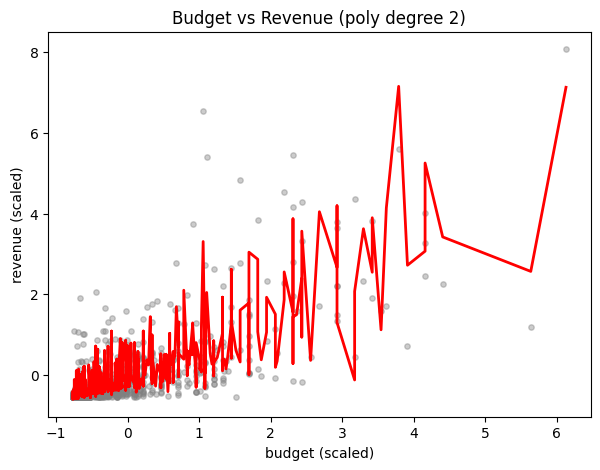

In [10]:
# show poly curve for one single feature: budget vs revenue
import numpy as np

b_idx = 0

order = np.argsort(X_test[:, b_idx])
b_sorted = X_test[order, b_idx]
pred_sorted = poly_pred[order]

plt.figure(figsize=(7, 5))
plt.scatter(X_test[:, b_idx], y_test, color='gray', alpha=0.4, s=15)   
plt.plot(b_sorted, pred_sorted, color='red', linewidth=2)             
plt.xlabel('budget (scaled)')
plt.ylabel('revenue (scaled)')
plt.title('Budget vs Revenue (poly degree 2)')
plt.show()


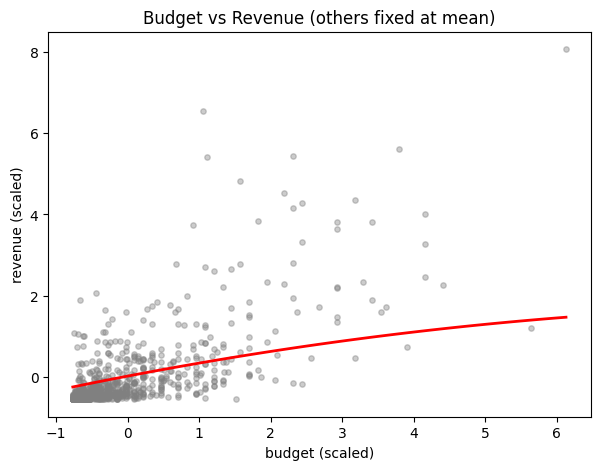

In [11]:
# keep other features fixed at their mean, change only budget
import numpy as np

b_idx = 0  

b_range = np.linspace(X_test[:, b_idx].min(), X_test[:, b_idx].max(), 100)

mean_row = X_test.mean(axis=0)
fake_X = np.tile(mean_row, (100, 1))   
fake_X[:, b_idx] = b_range             

fake_poly = poly.transform(fake_X)
fake_pred = pmodel.predict(fake_poly)   

plt.figure(figsize=(7, 5))
plt.scatter(X_test[:, b_idx], y_test, color='gray', alpha=0.4, s=15)
plt.plot(b_range, fake_pred, color='red', linewidth=2)
plt.xlabel('budget (scaled)')
plt.ylabel('revenue (scaled)')
plt.title('Budget vs Revenue (others fixed at mean)')
plt.show()
